# Notebook 01 — Data Exploration

**Owner:** Jyoti Kataria · **Reviewed by:** Ashfaaq KT
**Goal:** understand the structure, quality and distribution of the receipt data
*before* any model is trained, and record the defects the downstream notebooks
have to work around.

**Inputs:** `receipts_master.csv` (1,973 rows) · `labels.csv` (200) ·
`indian_category_folders.csv` (100)

---

## Findings at a glance

| # | Finding | Consequence |
|---|---|---|
| 1 | **`category` mixes two different taxonomies** — spend categories (`retail`, `restaurant`) and fraud labels (`genuine`, `tampered`) live in one column | Any model reading `category` naively trains on a meaningless 6-class target |
| 2 | **50.7% of dates and merchants are missing** — structurally, not at random: CORD (800 rows) never recorded them | Date/merchant features are unusable on half the corpus |
| 3 | **`total` has at least four incompatible formats** (`$8.20`, `22.000`, `20,000`, `8.70`) — **41% fail naive parsing** | `float()` silently drops 724 of 1,762 values |
| 4 | **Real Indian spend categories exist but are unused** — 11 human-assigned classes sitting in `indian_category_folders.csv` | NB 02 trains on 2 heuristic classes when richer ground truth is available |
| 5 | **Label set is imbalanced and partly single-annotator** | Affects fraud training (NB 03) and limits inter-annotator checks |

Each is evidenced below.

## 1. Setup and inventory

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = REPO / "dataset" / "processed"

receipts = pd.read_csv(PROCESSED / "receipts_master.csv")
labels   = pd.read_csv(PROCESSED / "labels.csv")
indian   = pd.read_csv(PROCESSED / "indian_category_folders.csv")

# Shared chart styling (validated categorical palette, light surface)
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
SURFACE, INK, GRID = "#fcfcfb", "#0b0b0b", "#dcdcd8"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": GREY, "axes.edgecolor": GRID,
    "xtick.color": GREY, "ytick.color": GREY, "font.size": 9,
    "axes.titlesize": 10.5, "figure.dpi": 110,
})

def style(ax, axis="y"):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, axis=axis, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    return ax

for name, frame in (("receipts_master", receipts), ("labels", labels),
                    ("indian_category_folders", indian)):
    print(f"{name:26s} {frame.shape[0]:5d} rows x {frame.shape[1]} cols")

receipts_master             1973 rows x 7 cols
labels                       200 rows x 4 cols
indian_category_folders      100 rows x 3 cols


In [2]:
print("receipts_master.csv — first 3 rows:\n")
display(receipts.head(3))
print("\nComposition by source dataset:")
display(receipts["source"].value_counts().to_frame("rows"))

receipts_master.csv — first 3 rows:



,image_path,merchant,date,total,category,items_text,source
0,dataset/temp_cord/image/receipt_00000.png,UNKNOWN,NaN,"1,591,600",restaurant,"Nasi Campur Bali (x 1), Bbk Bengil Nasi (x 1),...",CORD
1,dataset/temp_cord/image/receipt_00001.png,UNKNOWN,NaN,"580,965",restaurant,"SPGTHY BOLOGNASE (1), PEPPER AUS (1), WAGYU RI...",CORD
2,dataset/temp_cord/image/receipt_00002.png,UNKNOWN,NaN,"334,000",restaurant,"HAKAU UDANG (4), SIAO MAI BABI (4), CEKER AYAM...",CORD



Composition by source dataset:


,rows
source,
SROIE,973
CORD,800
processed_labels_arpan,200


## 2. Finding 1 — the `category` column holds two different taxonomies

This is the most consequential defect in the corpus. `category` is supposed to be
the spend category. It is not: for the 200 locally labelled receipts it holds the
*fraud* label instead.

In [3]:
print(receipts["category"].value_counts().to_frame("rows"))
print("\nCross-tabulated against the source dataset:\n")
display(pd.crosstab(receipts["category"], receipts["source"]))

             rows
category         
retail        973
restaurant    800
tampered      129
genuine        65
multi_bill      5
handwritten     1

Cross-tabulated against the source dataset:



source,CORD,SROIE,processed_labels_arpan
category,,,
genuine,0,0,65
handwritten,0,0,1
multi_bill,0,0,5
restaurant,800,0,0
retail,0,973,0
tampered,0,0,129


`retail` and `restaurant` are spend categories. `genuine`, `tampered`,
`multi_bill` and `handwritten` are **fraud labels** — a different question
entirely — and they enter only through the `processed_labels_arpan` source.

Any model that reads `category` as its target is training on a 6-class mixture of
two unrelated taxonomies. NB 02 avoids this by using the prepared
`category_dataset.csv` (spend classes only); this notebook records *why* that
extra preparation step exists.

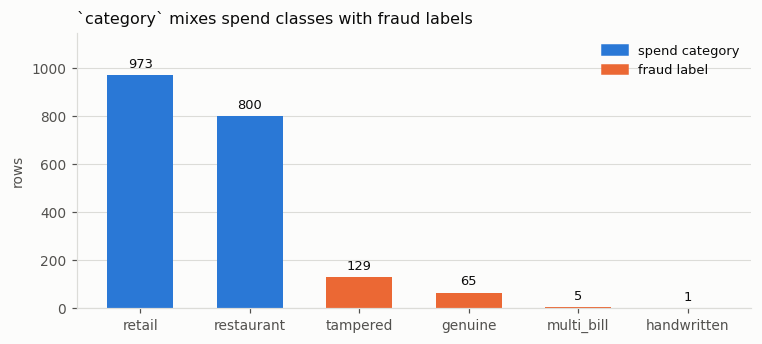

In [4]:
spend  = {"retail", "restaurant"}
fraud  = {"genuine", "tampered", "multi_bill", "handwritten"}
counts = receipts["category"].value_counts()

fig, ax = plt.subplots(figsize=(7, 3.2)); style(ax)
colours = [BLUE if c in spend else ORANGE for c in counts.index]
bars = ax.bar(counts.index, counts.values, color=colours, width=0.6)
ax.bar_label(bars, padding=3, fontsize=8.5, color=INK)
ax.set_ylabel("rows"); ax.set_title("`category` mixes spend classes with fraud labels", loc="left")
handles = [plt.Rectangle((0,0),1,1,color=BLUE), plt.Rectangle((0,0),1,1,color=ORANGE)]
ax.legend(handles, ["spend category", "fraud label"], frameon=False, fontsize=8.5)
ax.set_ylim(0, counts.max()*1.18); plt.tight_layout(); plt.show()

## 3. Finding 2 — missing data is concentrated, not spread evenly

In [5]:
missing = pd.DataFrame({
    "missing": receipts.isna().sum(),
    "% of rows": (receipts.isna().mean() * 100).round(1),
})
# 'UNKNOWN' is a placeholder, not a real merchant — count it as missing too.
missing.loc["merchant", "missing"] += int((receipts["merchant"] == "UNKNOWN").sum())
missing.loc["merchant", "% of rows"] = round(
    100 * ((receipts["merchant"] == "UNKNOWN") | receipts["merchant"].isna()).mean(), 1)
display(missing.sort_values("missing", ascending=False))

print("\nWhere does it come from? Missing rate by source:\n")
by_source = receipts.assign(
    no_date=receipts["date"].isna(),
    no_merchant=(receipts["merchant"] == "UNKNOWN") | receipts["merchant"].isna(),
    no_total=receipts["total"].isna(),
).groupby("source")[["no_date", "no_merchant", "no_total"]].mean().round(3) * 100
display(by_source.astype(str) + "%")

,missing,% of rows
merchant,1000,50.7
date,1000,50.7
items_text,347,17.6
total,211,10.7
image_path,0,0.0
category,0,0.0
source,0,0.0



Where does it come from? Missing rate by source:



,no_date,no_merchant,no_total
source,,,
CORD,100.0%,100.0%,1.2%
SROIE,0.0%,0.0%,0.1%
processed_labels_arpan,100.0%,100.0%,100.0%


The gap is **not random noise — it is structural**. CORD contributes 800 rows with
**no merchant or date at all** (its annotations simply do not include them), and
the 200 locally labelled rows carry a fraud label with no receipt metadata. SROIE,
by contrast, is complete on both fields.

That distinction matters: imputing these values would invent data rather than
recover it, because the information was never captured in the first place.

Practical consequence: `date` and `merchant` cannot be used as model features
across the whole corpus. NB 02 therefore classifies from `items_text`, which is
far better populated.

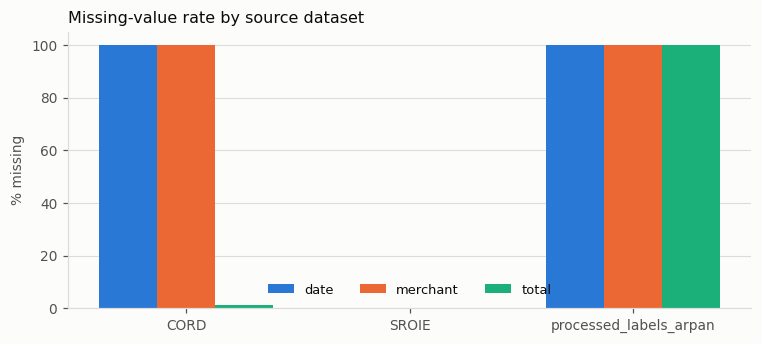

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2)); style(ax)
x = range(len(by_source.index))
w = 0.26
for offset, col, colour, label in ((-w, "no_date", BLUE, "date"),
                                   (0.0, "no_merchant", ORANGE, "merchant"),
                                   (w, "no_total", AQUA, "total")):
    ax.bar([i + offset for i in x], by_source[col], width=w, color=colour, label=label)
ax.set_xticks(list(x)); ax.set_xticklabels(by_source.index)
ax.set_ylabel("% missing"); ax.set_ylim(0, 105)
ax.set_title("Missing-value rate by source dataset", loc="left")
ax.legend(frameon=False, fontsize=8.5, ncol=3)
plt.tight_layout(); plt.show()

## 4. Finding 3 — `total` is not numeric, and fails silently

In [7]:
raw = receipts["total"].dropna().astype(str)
naive = pd.to_numeric(raw, errors="coerce")
print(f"non-null total values      : {len(raw)}")
print(f"parse as float directly    : {naive.notna().sum()}  "
      f"({naive.notna().mean():.1%})")
print(f"SILENTLY LOST by float()   : {naive.isna().sum()}\n")

print("Examples of what fails:")
display(raw[naive.isna()].value_counts().head(8).to_frame("count"))

non-null total values      : 1762
parse as float directly    : 1038  (58.9%)
SILENTLY LOST by float()   : 724

Examples of what fails:


,count
total,
$8.20,18
"20,000",15
"17,000",12
"28,000",11
"22,000",11
"45,000",10
"25,000",9
"42,000",8


`$8.20` carries a currency symbol, `20,000` uses a thousands separator, and
`22.000` is ambiguous — it is either twenty-two thousand (European convention) or
twenty-two point zero. **The dataset does not record which currency or convention
each row uses**, so those values cannot be disambiguated from the file alone.

This is why the reward engine takes its amount from the live OCR output rather
than from `receipts_master.csv`.

## 5. Finding 4 — real spend categories exist and are unused

In [8]:
print("Human-assigned categories from Jyoti's Drive folder structure:\n")
folder_counts = indian["drive_category_folder"].value_counts()
display(folder_counts.to_frame("receipts"))

print(f"\n{len(folder_counts)} real classes available, vs the "
      f"{receipts[receipts['category'].isin(['retail','restaurant'])]['category'].nunique()} "
      f"heuristic classes NB 02 currently trains on.")

Human-assigned categories from Jyoti's Drive folder structure:



,receipts
drive_category_folder,
Restaurant Bill,20
Online shopping bills,19
Grocery Bills,14
Pharmacy Bills,13
Garments stores bills,13
Traveling bills,7
Marble and Stones shop bill,4
Electricity and Water bill,4
Electronics shop,4



11 real classes available, vs the 2 heuristic classes NB 02 currently trains on.


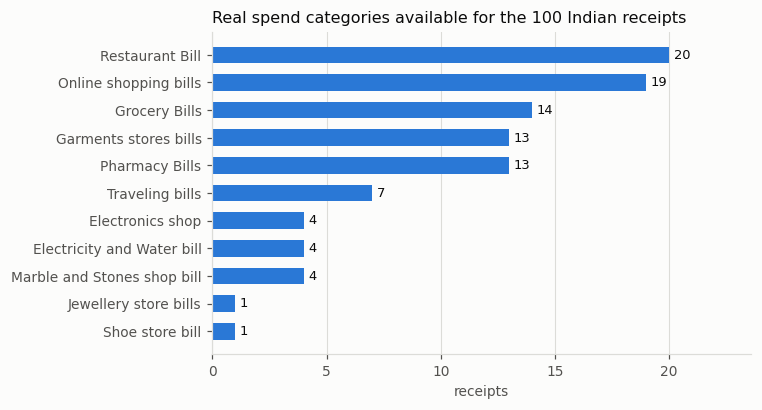

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.8)); style(ax, axis="x")
order = folder_counts.sort_values()
bars = ax.barh(order.index, order.values, color=BLUE, height=0.6)
ax.bar_label(bars, padding=3, fontsize=8.5, color=INK)
ax.set_xlabel("receipts"); ax.set_xlim(0, order.max()*1.18)
ax.set_title("Real spend categories available for the 100 Indian receipts", loc="left")
plt.tight_layout(); plt.show()

These 11 labels were assigned by a person organising the receipts into folders —
genuine ground truth, richer than the heuristic `retail` / `restaurant` split.
They cover only 100 receipts, so they cannot replace the current training set,
but they are a ready-made **held-out evaluation set** for the category classifier
and are currently unexploited.

## 6. Finding 5 — label distribution and annotator coverage

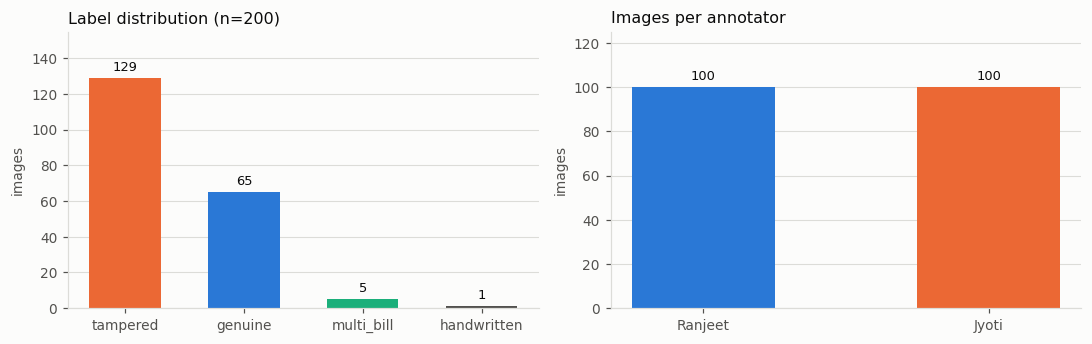

labelled_by  Jyoti  Ranjeet
label                      
genuine         65        0
handwritten      1        0
multi_bill       5        0
tampered        29      100


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

counts = labels["label"].value_counts()
style(axes[0])
bars = axes[0].bar(counts.index, counts.values,
                   color=[ORANGE, BLUE, AQUA, GREY][:len(counts)], width=0.6)
axes[0].bar_label(bars, padding=3, fontsize=8.5, color=INK)
axes[0].set_ylabel("images"); axes[0].set_ylim(0, counts.max()*1.2)
axes[0].set_title("Label distribution (n=200)", loc="left")

who = labels["labelled_by"].value_counts()
style(axes[1])
bars = axes[1].bar(who.index, who.values, color=[BLUE, ORANGE][:len(who)], width=0.5)
axes[1].bar_label(bars, padding=3, fontsize=8.5, color=INK)
axes[1].set_ylabel("images"); axes[1].set_ylim(0, who.max()*1.25)
axes[1].set_title("Images per annotator", loc="left")
plt.tight_layout(); plt.show()

print(pd.crosstab(labels["label"], labels["labelled_by"]))

Two observations that constrain the fraud work in NB 03:

- **Imbalance.** 129 tampered vs 65 genuine — roughly 2:1. NB 03 handles this with
  weighted cross-entropy rather than resampling.
- **No overlap between annotators.** Ranjeet labelled 100 images and Jyoti the
  other 100, with no receipt labelled by both. **Inter-annotator agreement
  therefore cannot be measured**, so there is no estimate of label noise — a real
  limitation to state when reporting fraud results.
- `multi_bill` (5) and `handwritten` (1) are too rare to train on and are excluded
  from the binary fraud task.

## 7. Integrity checks

In [11]:
print(f"duplicate image_path in receipts_master : "
      f"{receipts['image_path'].duplicated().sum()}")
print(f"duplicate image_path in labels          : "
      f"{labels['image_path'].duplicated().sum()}")
print(f"fully duplicated rows in receipts_master: {receipts.duplicated().sum()}")

missing_files = [p for p in labels["image_path"] if not (REPO / p).exists()]
print(f"\nlabelled images missing from disk       : {len(missing_files)} of {len(labels)}")

# Tampered images are derived from originals, so the independent unit is the
# source receipt, not the file — this is what drives grouped CV in NB 03.
import re
sources = labels["image_path"].map(
    lambda p: re.sub(r"_tampered(_v\d+)?$", "", Path(p).stem).strip().lower())
print(f"unique source receipts behind 200 images: {sources.nunique()}")

duplicate image_path in receipts_master : 0
duplicate image_path in labels          : 0
fully duplicated rows in receipts_master: 0

labelled images missing from disk       : 0 of 200
unique source receipts behind 200 images: 104


No duplicates and no missing files — but the last number is the important one:
**200 images derive from far fewer unique receipts.** Several tampered variants
share one original, so the images are not independent samples. NB 03 relies on
this fact and splits by source receipt rather than by file.

---

## 8. Conclusions and what each downstream notebook must do

| Notebook | Constraint arising from this exploration |
|---|---|
| **02 — classifier** | Use `category_dataset.csv`, never raw `category`. Classify from `items_text`; `date`/`merchant` are unusable on half the corpus. Consider `indian_category_folders.csv` as a held-out set. |
| **03 — fraud** | Split by source receipt, not by image. Handle 2:1 imbalance with weighted loss. Exclude `multi_bill`/`handwritten`. Label noise is unquantified — no annotator overlap. |
| **04 — collaborative filter** | No real user–item interactions exist; `synthetic_user_interactions.csv` is a placeholder and any result from it must be reported as synthetic. |
| **05 — reward engine** | Take amounts from live OCR, not from `total` — **41% of that column fails naive numeric parsing** and cannot be disambiguated without knowing the currency and decimal convention. |

**Recommended data fixes, in priority order**

1. Split `category` into `spend_category` and `fraud_label` — one column, two meanings, is a latent bug for every downstream consumer.
2. Record currency and decimal convention per source so `total` becomes usable.
3. Have both annotators label a shared subset of ~30 receipts so inter-annotator agreement can be reported.
4. Use the 11 real Indian spend categories as an evaluation set for NB 02.